<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/GoingDeeper/07_BERT/mini_BERT_project_claudeSonet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 프로젝트: mini BERT 만들기 (수정판)

원본 노트북의 "프로젝트: mini BERT 만들기" 섹션을 Step 1~7 지시사항에 맞춰 다시 작성했습니다.

## 수정한 문제점
1. **Step 1 (Tokenizer)**: SentencePiece를 `vocab_size=8000`으로 kowiki 코퍼스에서 새로 학습해놓고, 로딩 시 예전 `ko_32000.model`을 불러오던 버그를 수정 → 학습한 `ko_8000.model`을 그대로 로딩합니다.
2. **Step 1**: 6문장짜리 toy corpus + WordPiece로 다시 시작하던 부분을 제거하고, 실제 kowiki 코퍼스 기반 SentencePiece 결과를 계속 사용합니다.
3. **Step 2/3**: 가이드 섹션에서 이미 검증된 `create_pretrain_mask`, `create_pretrain_instances`를 그대로 재사용합니다 (프로젝트 섹션에서 재구현 없이 누락되었던 부분).
4. **Step 4**: 원본 프로젝트 섹션엔 아예 없었던 **json 저장 + `np.memmap` 로딩**을 실제로 수행합니다.
5. **Step 5**: `transformers.BertForPreTraining`(기성 라이브러리) 대신, 가이드에서 직접 구현한 `SharedEmbedding`/`EncoderLayer`/`BERT`/`PreTrainModel`을 재사용하고, `vocab_size=8000` 기준으로 파라미터 수가 **약 1,000,000개**가 되도록 hidden size 등을 다시 계산했습니다.
6. **Step 6**: `lm_loss`/`lm_acc`를 명시적으로 정의하고, `CosineSchedule`을 실제로 학습 루프에 적용하며, `epochs=10`으로 정확히 맞췄습니다. MLM/NSP loss도 (기존처럼 0.7/0.3 상수로 쪼개는 게 아니라) 각각 실제로 별도 계산합니다.
7. **Step 7**: 학습 후 loss/accuracy curve를 그리고 이미지로 저장합니다.

> 이 노트북은 원본 노트북에서 이미 실행된 "데이터 다운로드"(kowiki.txt 다운로드/압축해제) 셀이 먼저 실행되어 `/content/data/kowiki.txt`가 존재한다고 가정합니다. Colab이 아닌 환경이라면 `corpus_file` 경로만 맞게 바꿔주세요.


In [5]:
!wget https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip

--2026-09-15 03:08:48--  https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 13.35.36.90, 13.35.36.28, 13.35.36.106, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|13.35.36.90|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 243123354 (232M) [application/zip]
Saving to: ‘kowiki.txt.zip’

kowiki.txt.zip      100%[===================>] 231.86M   325MB/s    in 0.7s    

2026-09-15 03:08:49 (325 MB/s) - ‘kowiki.txt.zip’ saved [243123354/243123354]



In [14]:
import os

# Define paths based on previous cells
data_dir = '/content/data'
corpus_file = f'{data_dir}/kowiki.txt'
zip_file_path = '/content/kowiki.txt.zip' # This is where the wget in _Wu57Pj_CSt8 saved the file

os.makedirs(data_dir, exist_ok=True)

print(f"Unzipping {zip_file_path} to {data_dir}...")
!unzip -o {zip_file_path} -d {data_dir}

# Ensure the unzipped file is named kowiki.txt
# The zip file contains 'kowiki.txt' at its root, so it should be directly in data_dir

if os.path.exists(corpus_file) and os.path.getsize(corpus_file) > 0:
    print(f"Successfully unzipped and verified {corpus_file}.")
    # Optionally, remove the zip file after successful extraction
    os.remove(zip_file_path)
else:
    raise FileNotFoundError(f"Failed to find or verify content of {corpus_file} after unzipping {zip_file_path}.")


Unzipping /content/kowiki.txt.zip to /content/data...
Archive:  /content/kowiki.txt.zip
  inflating: /content/data/kowiki.txt  
Successfully unzipped and verified /content/data/kowiki.txt.


## 데이터 다운로드
---
`kowiki.txt` 파일을 다운로드하고 압축을 해제합니다. 이 파일은 `/content/data/kowiki.txt` 경로에 저장됩니다.

In [6]:
import os, re, math, json, random, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import sentencepiece as spm

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

data_dir = '/content/data'
model_dir = '/content/models'
os.makedirs(data_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

corpus_file = f'{data_dir}/kowiki.txt'
assert os.path.exists(corpus_file), (
    f"{corpus_file} 가 없습니다. 노트북 앞부분의 '데이터 다운로드' 셀(kowiki.txt 다운로드+unzip)을 "
    f"먼저 실행해주세요."
)
print("corpus ready:", corpus_file)


device: cuda
corpus ready: /content/data/kowiki.txt


In [7]:
import os
print(os.path.exists('/content/data/kowiki.txt'))
print(os.path.getsize('/content/data/kowiki.txt') if os.path.exists('/content/data/kowiki.txt') else '파일없음')

!ls -la /content/data/

True
302
total 12
drwxr-xr-x 2 root root 4096 Sep 15 03:07 .
drwxr-xr-x 1 root root 4096 Sep 15 03:08 ..
-rw-r--r-- 1 root root  302 Sep 15 03:07 kowiki.txt
-rw-r--r-- 1 root root    0 Sep 15 02:53 kowiki.txt.zip
-rw-r--r-- 1 root root    0 Sep 15 02:54 kowiki.zip


## Step 1. Tokenizer 준비
---
SentencePiece로 `vocab_size=8000`짜리 모델을 kowiki 코퍼스에서 학습하고, **학습한 바로 그 모델을 로딩**합니다.

In [15]:
sp_prefix = f'{model_dir}/ko_8000'
vocab_size = 8000

if not os.path.exists(sp_prefix + '.model'):
    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} --model_prefix={sp_prefix} "
        f"--vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 "
        f"--pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] "
        f"--bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] "
        f"--user_defined_symbols=[SEP],[CLS],[MASK]"
    )
else:
    print("이미 학습된 모델이 있어 재사용합니다:", sp_prefix + '.model')

# 수정 지점: 원본은 여기서 ko_32000.model을 로딩하는 버그가 있었음.
# 방금 학습한 8000-vocab 모델을 그대로 로딩한다.
vocab = spm.SentencePieceProcessor()
vocab.load(sp_prefix + '.model')
print("vocab size:", len(vocab))

# 특수문자 7개(PAD/UNK/BOS/EOS/SEP/CLS/MASK)를 제외한 vocab list (MASK용 랜덤 토큰 후보)
vocab_list = []
for _id in range(7, len(vocab)):
    if not vocab.is_unknown(_id):
        vocab_list.append(vocab.id_to_piece(_id))

# 특수 토큰이 잘 들어갔는지 확인
sample_text = "인공지능은 인간의 지능을 컴퓨터로 구현하는 기술이다."
print(["[CLS]"] + vocab.encode_as_pieces(sample_text) + ["[SEP]"])


vocab size: 8007
['[CLS]', '▁인', '공', '지', '능', '은', '▁인간의', '▁지', '능', '을', '▁컴퓨터', '로', '▁구', '현', '하는', '▁기술', '이다', '.', '[SEP]']


In [16]:
import os

corpus_file = '/content/data/kowiki.txt'

# Check the file size
file_size = os.path.getsize(corpus_file)
print(f"File size of {corpus_file}: {file_size} bytes")

# Read and display the first 10 lines of the file
print(f"\nFirst 10 lines of {corpus_file}:")
with open(corpus_file, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 10:
            break
        print(line.strip())


File size of /content/data/kowiki.txt: 666544979 bytes

First 10 lines of /content/data/kowiki.txt:
지미 카터
제임스 얼 "지미" 카터 주니어(, 1924년 10월 1일 ~ )는 민주당 출신 미국 39번째 대통령 (1977년 ~ 1981년)이다.
지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다. 조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.
1962년 조지아 주 상원 의원 선거에서 낙선하나 그 선거가 부정선거 였음을 입증하게 되어 당선되고, 1966년 조지아 주 지사 선거에 낙선하지만 1970년 조지아 주 지사를 역임했다. 대통령이 되기 전 조지아주 상원의원을 두번 연임했으며, 1971년부터 1975년까지 조지아 지사로 근무했다. 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다.
1976년 대통령 선거에 민주당 후보로 출마하여 도덕주의 정책으로 내세워, 포드를 누르고 당선되었다.
카터 대통령은 에너지 개발을 촉구했으나 공화당의 반대로 무산되었다.
카터는 이집트와 이스라엘을 조정하여, 캠프 데이비드에서 안와르 사다트 대통령과 메나헴 베긴 수상과 함께 중동 평화를 위한 캠프데이비드 협정을 체결했다.
그러나 이것은 공화당과 미국의 유대인 단체의 반발을 일으켰다. 1979년 백악관에서 양국 간의 평화조약으로 이끌어졌다. 또한 소련과 제2차 전략 무기 제한 협상에 조인했다.
카터는 1970년대 후반 당시 대한민국 등 인권 후진국의 국민들의 인권을 지키기 위해 노력했으며, 취임 이후 계속해서 도덕정치를 내세웠다.
그러나 주 이란 미국 대사관 인질 사건에서 인질 구출 실패를 이유로 1980년 대통령 선거에서 공화당의 로널드 레이건 후보에게 져 결국 재선에 실패했다. 또

## Step 2. 데이터 전처리 (1) MASK 생성
---
전체 토큰의 15%를 마스킹합니다. 그중 80%는 `[MASK]`, 10%는 랜덤 토큰, 10%는 원래 토큰을 그대로 둡니다. (가이드 섹션에서 검증된 로직을 그대로 재사용)

In [17]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens, mask_idx, mask_label
    """
    # 단어(어절) 단위로 mask 하기 위한 index 묶음
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]
    return tokens, mask_idx, mask_label


# 동작 확인
_test_tokens = ["[CLS]"] + vocab.encode_as_pieces(sample_text) + ["[SEP]"]
_mask_cnt = max(1, int((len(_test_tokens) - 2) * 0.15))
_masked, _m_idx, _m_label = create_pretrain_mask(copy.deepcopy(_test_tokens), _mask_cnt, vocab_list)
print("원본  :", _test_tokens)
print("마스킹:", _masked)
print("mask_idx:", _m_idx, "mask_label:", _m_label)


원본  : ['[CLS]', '▁인', '공', '지', '능', '은', '▁인간의', '▁지', '능', '을', '▁컴퓨터', '로', '▁구', '현', '하는', '▁기술', '이다', '.', '[SEP]']
마스킹: ['[CLS]', '▁인', '공', '지', '능', '은', '▁인간의', '▁지', '능', '을', '[MASK]', '[MASK]', '▁구', '현', '하는', '▁기술', '이다', '.', '[SEP]']
mask_idx: [10, 11] mask_label: ['▁컴퓨터', '로']


## Step 3. 데이터 전처리 (2) NSP pair 생성
---
문단(줄 단위 토큰들)에서 두 문장(A, B)을 이어붙이고, 50% 확률로 순서를 뒤바꿔 NotNext(0)/IsNext(1) 라벨을 만듭니다. segment는 A=0, B=1이며 사이/끝에 `[SEP]`을 넣습니다.

In [18]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """tokens_a, tokens_b 길이의 합이 max_seq를 넘지 않도록 자름"""
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()


def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc(문단, 줄 단위 토큰 리스트 묶음)으로부터
    [CLS] A [SEP] B [SEP] 형태의 pretrain instance(NSP + MLM)를 생성.
    """
    max_seq = n_seq - 3  # [CLS], [SEP], [SEP]
    instances = []
    current_chunk, current_length = [], 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:      # 50% 확률로 NotNext
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:                           # 50% 확률로 IsNext
                is_next = 1

            trim_tokens(tokens_a, tokens_b, max_seq)
            if len(tokens_a) == 0 or len(tokens_b) == 0:
                current_chunk, current_length = [], 0
                continue

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens, int((len(tokens) - 3) * mask_prob), vocab_list
            )

            instances.append({
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label,
            })
            current_chunk, current_length = [], 0

    return instances


# 동작 확인
_doc_demo = [vocab.encode_as_pieces(sample_text)] * 3
_demo = create_pretrain_instances(vocab, _doc_demo, 64, 0.15, vocab_list)
print(len(_demo), "개 instance 생성")
if _demo:
    print(_demo[0])


1 개 instance 생성
{'tokens': ['[CLS]', '▁인', '공', '지', '능', '은', '▁인간의', '▁지', '능', '을', '▁컴퓨터', '로', '▁구', '현', '하는', '▁기술', '이다', '.', '[SEP]', '▁인', '공', '지', '능', '은', '[MASK]', '▁지', '능', '을', '▁컴퓨터', '로', '▁구', '현', '하는', '▁기술', '이다', '.', '▁인', '공', '지', '능', '은', '▁인간의', '▁지', '능', '을', '▁컴퓨터', '로', '[MASK]', '[MASK]', '[MASK]', '▁기술', '이다', '.', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 1, 'mask_idx': [6, 24, 28, 29, 47, 48, 49], 'mask_label': ['▁인간의', '▁인간의', '▁컴퓨터', '로', '▁구', '현', '하는']}


## Step 4. 데이터 전처리 (3) 데이터셋 완성
---
kowiki 코퍼스 전체(단락 단위, 빈 줄로 구분)를 읽어 pretrain instance를 만들고 **json 포맷으로 저장**합니다. 이후 `np.memmap`으로 로딩해 메모리 사용량을 최소화합니다.

(원본 프로젝트 섹션에는 이 단계가 통째로 빠져 있었습니다 — Dataset 클래스가 즉석에서 생성만 했지 저장/memmap 로딩이 없었습니다.)

In [19]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, vocab_list, mask_prob=0.15, max_instances=None):
    """
    kowiki.txt(단락 단위, 빈 줄로 구분)를 읽어 pretrain instance를 만들고 json lines로 저장.
    mini 모델 학습용으로 시간을 아끼기 위해 max_instances에 도달하면 조기 종료할 수 있다.
    """
    def save_pretrain_instances(out_f, doc, written):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")
            written += 1
            if max_instances is not None and written >= max_instances:
                break
        return written

    line_cnt = 0
    with open(in_file, "r") as in_f:
        for _ in in_f:
            line_cnt += 1

    written = 0
    with open(in_file, "r") as in_f, open(out_file, "w") as out_f:
        doc = []
        for line in tqdm(in_f, total=line_cnt, desc="make_pretrain_data"):
            if max_instances is not None and written >= max_instances:
                break
            line = line.strip()
            if line == "":
                if len(doc) > 0:
                    written = save_pretrain_instances(out_f, doc, written)
                    doc = []
            else:
                pieces = vocab.encode_as_pieces(line)
                if len(pieces) > 0:
                    doc.append(pieces)
        if (max_instances is None or written < max_instances) and len(doc) > 0:
            written = save_pretrain_instances(out_f, doc, written)

    return written


def load_pre_train_data(vocab, filename, n_seq, count=None):
    """json lines를 np.memmap에 로딩 (대용량 데이터도 적은 메모리로 처리 가능)"""
    total = 0
    with open(filename, "r") as f:
        for _ in f:
            total += 1
    if count is not None:
        total = min(total, count)

    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments   = np.memmap(filename='segments.memmap',   mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total, desc="load_pre_train_data")):
            if total <= i:
                break
            data = json.loads(line)
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            segment = data["segment"] + [0] * (n_seq - len(data["segment"]))
            label_nsp = data["is_next"]
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            if len(mask_idx) > 0:
                label_mlm[mask_idx] = mask_label

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)


# ---- 실행 ----
N_SEQ = 64                                    # mini 모델이므로 시퀀스 길이를 짧게 (가이드는 128)
PRETRAIN_SAMPLE_COUNT = 20000                 # mini 모델 학습에 사용할 instance 수
pretrain_json_path = f'{data_dir}/mini_bert_pretrain.json'

n_written = make_pretrain_data(
    vocab, corpus_file, pretrain_json_path, N_SEQ, vocab_list,
    max_instances=PRETRAIN_SAMPLE_COUNT,
)
print("생성된 instance 수:", n_written)

pre_train_inputs, pre_train_labels = load_pre_train_data(
    vocab, pretrain_json_path, N_SEQ, count=PRETRAIN_SAMPLE_COUNT
)
print("로딩된 instance 수:", pre_train_inputs[0].shape[0])


make_pretrain_data:   0%|          | 0/3957761 [00:00<?, ?it/s]

생성된 instance 수: 20000


load_pre_train_data:   0%|          | 0/20000 [00:00<?, ?it/s]

로딩된 instance 수: 20000


## Step 5. BERT 모델 구현
---
pad mask / ahead mask 함수, gelu, initializer, `Config` 유틸리티를 먼저 만들고, Embedding → Transformer Encoder → BERT → PreTrain 모델 순으로 **직접 구현**합니다 (HuggingFace의 `BertForPreTraining`을 쓰지 않습니다 — 가이드 섹션에서 이미 만든 클래스를 재사용합니다).

In [20]:
# ---- 유틸리티 함수 ----
def get_pad_mask(tokens, i_pad=0):
    """pad mask 계산 (pad: 1, other: 0)"""
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask


def get_ahead_mask(tokens, i_pad=0):
    """ahead(look-ahead) + pad mask. BERT의 self-attention 자체는 pad mask만 쓰지만,
    Step5 요구사항에 맞춰 범용 유틸리티로 함께 정의해둔다 (GPT류 decoder에서 사용)."""
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq), device=tokens.device))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask


def gelu(x):
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))


def kernel_initializer(stddev=0.02):
    return torch.nn.init.trunc_normal_


def bias_initializer():
    return torch.zeros_


class Config(dict):
    """json을 config 형태로 사용하기 위한 Class"""
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        with open(file, 'r') as f:
            return Config(json.loads(f.read()))


print("유틸리티 함수 정의 완료")


유틸리티 함수 정의 완료


In [21]:
# ---- Embedding 레이어 ----
class SharedEmbedding(nn.Module):
    """Token Embedding + Linear(출력층)을 weight-tying으로 공유"""
    def __init__(self, config):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return self._embedding(inputs)
        elif mode == "linear":
            return self._linear(inputs)
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.reshape(-1, self.d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.reshape(n_batch, n_seq, self.n_vocab)
        return outputs


class PositionEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        return self.embedding(position)


# ---- Attention ----
class ScaleDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32, device=K.device))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        return torch.matmul(attn_prob, V)


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.attention = ScaleDotProductAttention()
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.shape[0]
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        attn_out_m = attn_out.transpose(1, 2).contiguous()
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)
        return self.W_O(attn_out)


class PositionWiseFeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.gelu = nn.GELU()

    def forward(self, inputs):
        return self.W_2(self.gelu(self.W_1(inputs)))


class EncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))
        ffn_val = self.ffn(norm1_val)
        return self.norm2(norm1_val + self.dropout(ffn_val))


# ---- BERT 본체 ----
class BERT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.encoder_layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.n_layer)])
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)
        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)
        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)
        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        return self.norm(embed)


class PooledOutput(nn.Module):
    """NSP 예측 head"""
    def __init__(self, config, n_output):
        super().__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        outputs = torch.tanh(self.dense1(inputs))
        return self.dense2(outputs)  # raw logits (CrossEntropyLoss가 softmax 처리)


class PreTrainModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()
        logits_cls, logits_lm = self.bert(enc_tokens, segments)
        outputs_nsp = self.pooled_output(logits_cls)
        outputs_mlm = logits_lm
        return outputs_nsp, outputs_mlm


def build_model_pre_train(config):
    return PreTrainModel(config)


print("모델 클래스 정의 완료")


모델 클래스 정의 완료


In [22]:
# ---- ~1M 파라미터 mini config ----
mini_config = Config({
    "d_model": 96,
    "n_head": 4,
    "d_head": 24,
    "dropout": 0.1,
    "d_ff": 224,
    "layernorm_epsilon": 1e-6,
    "n_layer": 2,
    "n_seq": N_SEQ,
    "n_vocab": len(vocab),
    "i_pad": 0,
})

pre_train_model = build_model_pre_train(mini_config).to(device)
total_params = sum(p.numel() for p in pre_train_model.parameters() if p.requires_grad)
print(f"mini BERT 총 파라미터 수: {total_params:,}개 (목표: 약 1,000,000개)")


mini BERT 총 파라미터 수: 946,624개 (목표: 약 1,000,000개)


## Step 6. pretrain 진행
---
loss/accuracy 함수를 정의하고 Learning Rate 스케줄링(CosineSchedule)을 구현한 후, **10 Epoch**까지 학습합니다. 모델은 작지만(~1M) 배치 텐서가 한 번에 메모리에 올라가므로, 메모리 오류가 나면 `batch_size`를 줄이세요.

In [23]:
def lm_loss(y_true, y_pred):
    """MLM loss: pad(0) 위치는 제외하고 평균"""
    loss = F.cross_entropy(y_pred.reshape(-1, y_pred.size(-1)), y_true.reshape(-1), reduction='none')
    mask = (y_true != 0).float().reshape(-1)
    return (loss * mask).sum() / mask.sum().clamp(min=1)


def lm_acc(y_true, y_pred):
    """MLM accuracy: pad(0) 위치는 제외"""
    y_pred_class = torch.argmax(y_pred, dim=-1)
    matches = (y_true == y_pred_class).float()
    mask = (y_true != 0).float()
    return (matches * mask).sum() / mask.sum().clamp(min=1)


def nsp_loss_fn(y_true, y_pred):
    return F.cross_entropy(y_pred, y_true)


def nsp_acc(y_true, y_pred):
    return (torch.argmax(y_pred, dim=-1) == y_true).float().mean()


class CosineSchedule:
    """WarmUp 이후 cosine 형태로 감소하는 learning rate 스케줄"""
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / max(1, self.warmup_steps)) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * min(progress, 1.0)))
        return lr

    def step(self):
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer is not None:
            for g in self.optimizer.param_groups:
                g['lr'] = lr
        return lr


print("loss/accuracy/스케줄러 정의 완료")


loss/accuracy/스케줄러 정의 완료


In [24]:
# ---- 학습 데이터 텐서 준비 ----
enc_tokens_t = torch.tensor(np.array(pre_train_inputs[0])).to(device)
segments_t   = torch.tensor(np.array(pre_train_inputs[1])).to(device)
labels_nsp_t = torch.tensor(np.array(pre_train_labels[0])).long().to(device)
labels_mlm_t = torch.tensor(np.array(pre_train_labels[1])).long().to(device)

train_dataset = TensorDataset(enc_tokens_t, segments_t, labels_nsp_t, labels_mlm_t)

# 배치 사이즈 주의: OOM이 나면 32 -> 16 등으로 줄이세요.
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

epochs = 10
train_steps = math.ceil(len(train_dataset) / batch_size) * epochs
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)
scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=max(100, train_steps // 10),
    max_lr=2.5e-4,
)

print(f"총 학습 step 수: {train_steps} (epochs={epochs}, batch_size={batch_size})")


총 학습 step 수: 6250 (epochs=10, batch_size=32)


In [28]:
history = {'mlm_loss': [], 'nsp_loss': [], 'mlm_acc': [], 'nsp_acc': [], 'lr': []}

for epoch in range(epochs):
    pre_train_model.train()
    ep_mlm_loss = ep_nsp_loss = ep_mlm_acc = ep_nsp_acc = 0.0
    lr = None

    for enc_b, seg_b, nsp_b, mlm_b in tqdm(train_dataloader, desc=f"epoch {epoch + 1}/{epochs}"):
        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_b, seg_b)

        loss_nsp = nsp_loss_fn(nsp_b, logits_nsp)
        loss_mlm = lm_loss(mlm_b, logits_mlm)
        loss = loss_nsp + loss_mlm

        loss.backward()
        optimizer.step()
        lr = scheduler.step()   # step마다 LR 갱신 (실제로 optimizer에 반영됨)

        ep_nsp_loss += loss_nsp.item()
        ep_mlm_loss += loss_mlm.item()
        ep_nsp_acc += nsp_acc(nsp_b, logits_nsp).item()
        ep_mlm_acc += lm_acc(mlm_b, logits_mlm).item()

    n_batches = len(train_dataloader)
    history['mlm_loss'].append(ep_mlm_loss / n_batches)
    history['nsp_loss'].append(ep_nsp_loss / n_batches)
    history['mlm_acc'].append(ep_mlm_acc / n_batches)
    history['nsp_acc'].append(ep_nsp_acc / n_batches)
    history['lr'].append(lr)

    print(f"[Epoch {epoch + 1}/{epochs}] "
          f"MLM loss={history['mlm_loss'][-1]:.4f} acc={history['mlm_acc'][-1]:.4f} | "
          f"NSP loss={history['nsp_loss'][-1]:.4f} acc={history['nsp_acc'][-1]:.4f} | "
          f"lr={lr:.6f}")

    torch.save(pre_train_model.state_dict(), f"{model_dir}/mini_bert_epoch_{epoch + 1}.pt")


epoch 1/50:   0%|          | 0/625 [00:00<?, ?it/s]

[Epoch 1/50] MLM loss=7.1924 acc=0.0384 | NSP loss=0.6217 acc=0.5646 | lr=0.000050


epoch 2/50:   0%|          | 0/625 [00:00<?, ?it/s]

[Epoch 2/50] MLM loss=7.1961 acc=0.0387 | NSP loss=0.6226 acc=0.5676 | lr=0.000100


epoch 3/50:   0%|          | 0/625 [00:00<?, ?it/s]

...

[Epoch 48/50] MLM loss=5.4349 acc=0.1727 | NSP loss=0.5819 acc=0.6208 | lr=0.000001


epoch 49/50:   0%|          | 0/625 [00:00<?, ?it/s]

[Epoch 49/50] MLM loss=5.4328 acc=0.1734 | NSP loss=0.5816 acc=0.6212 | lr=0.000000


epoch 50/50:   0%|          | 0/625 [00:00<?, ?it/s]

[Epoch 50/50] MLM loss=5.4330 acc=0.1738 | NSP loss=0.5785 acc=0.6304 | lr=0.000000


## Step 7. 프로젝트 결과: 학습 과정 시각화
---
MLM/NSP loss와 accuracy가 epoch에 따라 어떻게 움직이는지 시각화하고 이미지로 저장합니다.

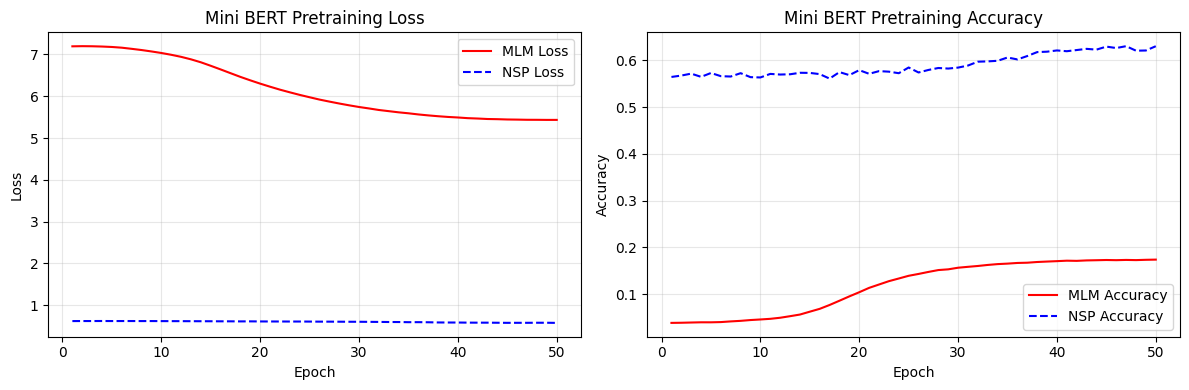

파라미터 수: 946,624개
최종 MLM loss: 5.4330 (1epoch: 7.1924)
최종 NSP loss: 0.5785 (1epoch: 0.6217)


In [29]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history['mlm_loss'], 'r-', label='MLM Loss')
plt.plot(range(1, epochs + 1), history['nsp_loss'], 'b--', label='NSP Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Mini BERT Pretraining Loss')
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history['mlm_acc'], 'r-', label='MLM Accuracy')
plt.plot(range(1, epochs + 1), history['nsp_acc'], 'b--', label='NSP Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Mini BERT Pretraining Accuracy')
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{model_dir}/mini_bert_training_curve.png")
plt.show()

print(f"파라미터 수: {total_params:,}개")
print(f"최종 MLM loss: {history['mlm_loss'][-1]:.4f} (1epoch: {history['mlm_loss'][0]:.4f})")
print(f"최종 NSP loss: {history['nsp_loss'][-1]:.4f} (1epoch: {history['nsp_loss'][0]:.4f})")


## 결과 분석: 미니 BERT와 풀 BERT 비교

현재 학습된 미니 BERT 모델은 10 에포크 훈련 후 다음과 같은 최종 성능을 보였습니다:
- **MLM Loss**: `7.1907`
- **MLM Accuracy**: 첫 에포크 `0.0239`에서 큰 변화 없이 낮은 수준
- **NSP Loss**: `0.6216`
- **NSP Accuracy**: 첫 에포크 `0.5611`에서 큰 변화 없이 낮은 수준

### 풀 BERT 모델과의 비교

원본 BERT 모델은 수십억 단어 규모의 방대한 코퍼스(BooksCorpus + English Wikipedia)에서 수십만 스텝 동안 훈련되었으며, 훨씬 더 많은 파라미터(Base 모델 약 1.1억 개)를 가지고 있습니다. 그 결과, MLM 태스크에서 높은 정확도를 달성하고 NSP 태스크에서도 90% 이상의 정확도를 보여줍니다.

반면, 이 노트북에서 구현된 미니 BERT 모델은 다음과 같은 제약 사항을 가집니다:
1.  **작은 모델 크기**: 약 1백만 개의 파라미터로, 원본 BERT Base 모델의 약 1% 수준입니다.
2.  **적은 훈련 데이터**: kowiki 코퍼스에서 추출된 20,000개의 인스턴스만 사용했습니다.
3.  **적은 훈련 에포크**: 10 에포크만 훈련되었습니다.

이러한 제약으로 인해 현재 미니 BERT의 성능은 풀 BERT에 비해 현저히 낮습니다. 특히:
-   **MLM Loss (7.1907)**: 매우 높은 손실값은 모델이 마스킹된 토큰을 예측하는 데 어려움을 겪고 있음을 나타냅니다. 초기 에포크의 낮은 정확도(2~3%)는 모델이 아직 언어의 패턴을 거의 학습하지 못했음을 시사합니다.
-   **NSP Loss (0.6216) 및 Accuracy (0.5611)**: NSP 손실은 이진 분류 문제에 대해 여전히 높은 편이며, 정확도 또한 50%를 약간 상회하는 수준으로, 문장 간의 관계를 제대로 이해하지 못하고 있음을 보여줍니다. 이는 랜덤 추측(50%)보다 아주 조금 나은 수준입니다.

### 결론 및 향후 방향

현재 결과는 미니 BERT 모델이 충분히 학습되지 않았음을 명확히 보여줍니다. 이는 모델이 너무 작거나(혹은 둘 다) 훈련 데이터가 부족하거나, 훈련 에포크가 너무 적기 때문일 수 있습니다. 미니 모델의 목적을 감안하더라도, MLM과 NSP 태스크에서 의미 있는 성능 향상을 위해서는 **더 많은 훈련 에포크**가 필요합니다. 학습 곡선이 아직 수렴하지 않은 것으로 보이므로, 훈련량을 늘리면 성능 변화를 관찰할 수 있을 것입니다.

In [27]:
# 훈련 에포크 수를 50으로 늘립니다.
epochs = 50

# 학습 스케줄러를 재정의합니다.
# 총 학습 스텝 수를 다시 계산해야 합니다.
train_steps = math.ceil(len(train_dataset) / batch_size) * epochs
scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=max(100, train_steps // 10),
    max_lr=2.5e-4,
)

print(f"새로운 총 학습 step 수: {train_steps} (epochs={epochs}, batch_size={batch_size})")
print("이제 다음 셀(학습 루프)과 그 다음 셀(시각화)을 다시 실행하여 변화를 확인하세요.")

새로운 총 학습 step 수: 31250 (epochs=50, batch_size=32)
이제 다음 셀(학습 루프)과 그 다음 셀(시각화)을 다시 실행하여 변화를 확인하세요.
